<a href="https://colab.research.google.com/github/Cristo-salva/Cristo-salva/blob/main/Challenge_Telecom_X_parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
dados = pd.read_csv('/content/dados_tratados.csv')

In [3]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerID               7032 non-null   object 
 1   Churn                    7032 non-null   object 
 2   gender                   7032 non-null   object 
 3   SeniorCitizen            7032 non-null   int64  
 4   Partner                  7032 non-null   object 
 5   Dependents               7032 non-null   object 
 6   tenure                   7032 non-null   int64  
 7   PhoneService             7032 non-null   object 
 8   MultipleLines            7032 non-null   object 
 9   InternetService          7032 non-null   object 
 10  OnlineSecurity           7032 non-null   object 
 11  OnlineBackup             7032 non-null   object 
 12  DeviceProtection         7032 non-null   object 
 13  TechSupport              7032 non-null   object 
 14  StreamingTV             

In [7]:
dados = dados.drop('customerID', axis = 1)

KeyError: "['customerID'] not found in axis"

In [8]:
display(dados.head())

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias_estimado,Contas_Diarias_preciso,tempo_contrato_ano,gasto_total_cliente
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,One year,Yes,Mailed check,65.6,593.30,19.8,2.2,0-1 ano,0-3.000
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,Yes,Month-to-month,No,Mailed check,59.9,542.40,18.1,2.0,0-1 ano,0-3.000
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,73.9,280.85,9.4,2.3,0-1 ano,0-3.000
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,41.3,3.1,1-2 anos,0-3.000
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Mailed check,83.9,267.40,8.9,2.9,0-1 ano,0-3.000


In [10]:
#Encoding
colunas_categoricas = dados.select_dtypes(include='object').columns.tolist()
colunas_categoricas.remove('Churn')

#One-Hot Encoding
dados_encoded = pd.get_dummies(dados, columns=colunas_categoricas, drop_first=True)

In [11]:
display(dados_encoded.head())

,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Contas_Diarias_estimado,Contas_Diarias_preciso,gender_Male,Partner_Yes,Dependents_Yes,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tempo_contrato_ano_1-2 anos,tempo_contrato_ano_2-3 anos,tempo_contrato_ano_3-4 anos,tempo_contrato_ano_4-5 anos,tempo_contrato_ano_5-6 anos,gasto_total_cliente_3.000-6.000,gasto_total_cliente_6.000-9.000
0,No,0,9,65.6,593.30,19.8,2.2,False,True,True,...,False,False,True,False,False,False,False,False,False,False
1,No,0,9,59.9,542.40,18.1,2.0,True,False,False,...,False,False,True,False,False,False,False,False,False,False
2,Yes,0,4,73.9,280.85,9.4,2.3,True,False,False,...,False,True,False,False,False,False,False,False,False,False
3,Yes,1,13,98.0,1237.85,41.3,3.1,True,True,False,...,False,True,False,True,False,False,False,False,False,False
4,Yes,1,3,83.9,267.40,8.9,2.9,False,True,False,...,False,False,True,False,False,False,False,False,False,False


In [12]:
dados_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7032 non-null   object 
 1   SeniorCitizen                          7032 non-null   int64  
 2   tenure                                 7032 non-null   int64  
 3   Charges.Monthly                        7032 non-null   float64
 4   Charges.Total                          7032 non-null   float64
 5   Contas_Diarias_estimado                7032 non-null   float64
 6   Contas_Diarias_preciso                 7032 non-null   float64
 7   gender_Male                            7032 non-null   bool   
 8   Partner_Yes                            7032 non-null   bool   
 9   Dependents_Yes                         7032 non-null   bool   
 10  PhoneService_Yes                       7032 non-null   bool   
 11  Mult

In [13]:
# Calcular a contagem de cada classe na coluna 'Churn'
churn_counts = dados_encoded['Churn'].value_counts()

# Calcular a proporção de cada classe
churn_proportions = dados_encoded['Churn'].value_counts(normalize=True)

# Exibir os resultados
print("Contagem de clientes por Churn:")
print(churn_counts)
print("\nProporção de clientes por Churn:")
print(churn_proportions)

Contagem de clientes por Churn:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Proporção de clientes por Churn:
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


In [14]:
!pip install imbalanced-learn

Agora, vamos aplicar o SMOTE para balancear as classes. Precisaremos separar as features (X) da variável alvo (y) antes de aplicar a técnica.

In [15]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Separar features (X) e target (y)
X = dados_encoded.drop('Churn', axis=1)
y = dados_encoded['Churn']

# Converter a variável alvo 'Churn' para numérica (0 para 'No', 1 para 'Yes')
y = y.map({'No': 0, 'Yes': 1})

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Exibir a contagem de classes após o SMOTE para verificar o balanceamento
print("Contagem de classes após SMOTE:")
print(y_res.value_counts())

Contagem de classes após SMOTE:
Churn
0    5163
1    5163
Name: count, dtype: int64


In [16]:
from sklearn.preprocessing import StandardScaler

# Inicializar o StandardScaler
scaler = StandardScaler()

# Padronizar as features (X_res)
X_res_scaled = scaler.fit_transform(X_res)

# O resultado do fit_transform é um array numpy, podemos convertê-lo de volta para DataFrame
# para manter os nomes das colunas, se necessário para análise posterior ou depuração
X_res_scaled = pd.DataFrame(X_res_scaled, columns=X_res.columns)

# Exibir as primeiras linhas dos dados padronizados
display(X_res_scaled.head())

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Contas_Diarias_estimado,Contas_Diarias_preciso,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tempo_contrato_ano_1-2 anos,tempo_contrato_ano_2-3 anos,tempo_contrato_ano_3-4 anos,tempo_contrato_ano_4-5 anos,tempo_contrato_ano_5-6 anos,gasto_total_cliente_3.000-6.000,gasto_total_cliente_6.000-9.000
0,-0.396364,-0.779515,-0.085022,-0.665746,-0.665425,-0.037144,-1.166982,0.998645,1.532046,0.296804,...,-0.527529,-0.961798,1.798733,-0.440806,-0.368915,-0.347049,-0.348273,-0.430104,-0.484331,-0.303323
1,-0.396364,-0.779515,-0.283624,-0.689018,-0.688744,-0.248137,0.856911,-1.001357,-0.652722,0.296804,...,-0.527529,-0.961798,1.798733,-0.440806,-0.368915,-0.347049,-0.348273,-0.430104,-0.484331,-0.303323
2,-0.396364,-0.988057,0.204170,-0.808603,-0.808077,0.068352,0.856911,-1.001357,-0.652722,0.296804,...,-0.527529,1.039719,-0.555947,-0.440806,-0.368915,-0.347049,-0.348273,-0.430104,-0.484331,-0.303323
3,2.522933,-0.612681,1.043872,-0.371047,-0.370520,0.912324,0.856911,0.998645,-0.652722,0.296804,...,-0.527529,1.039719,-0.555947,2.268574,-0.368915,-0.347049,-0.348273,-0.430104,-0.484331,-0.303323
4,2.522933,-1.029765,0.552594,-0.814753,-0.814936,0.701331,-1.166982,0.998645,-0.652722,0.296804,...,-0.527529,-0.961798,1.798733,-0.440806,-0.368915,-0.347049,-0.348273,-0.430104,-0.484331,-0.303323


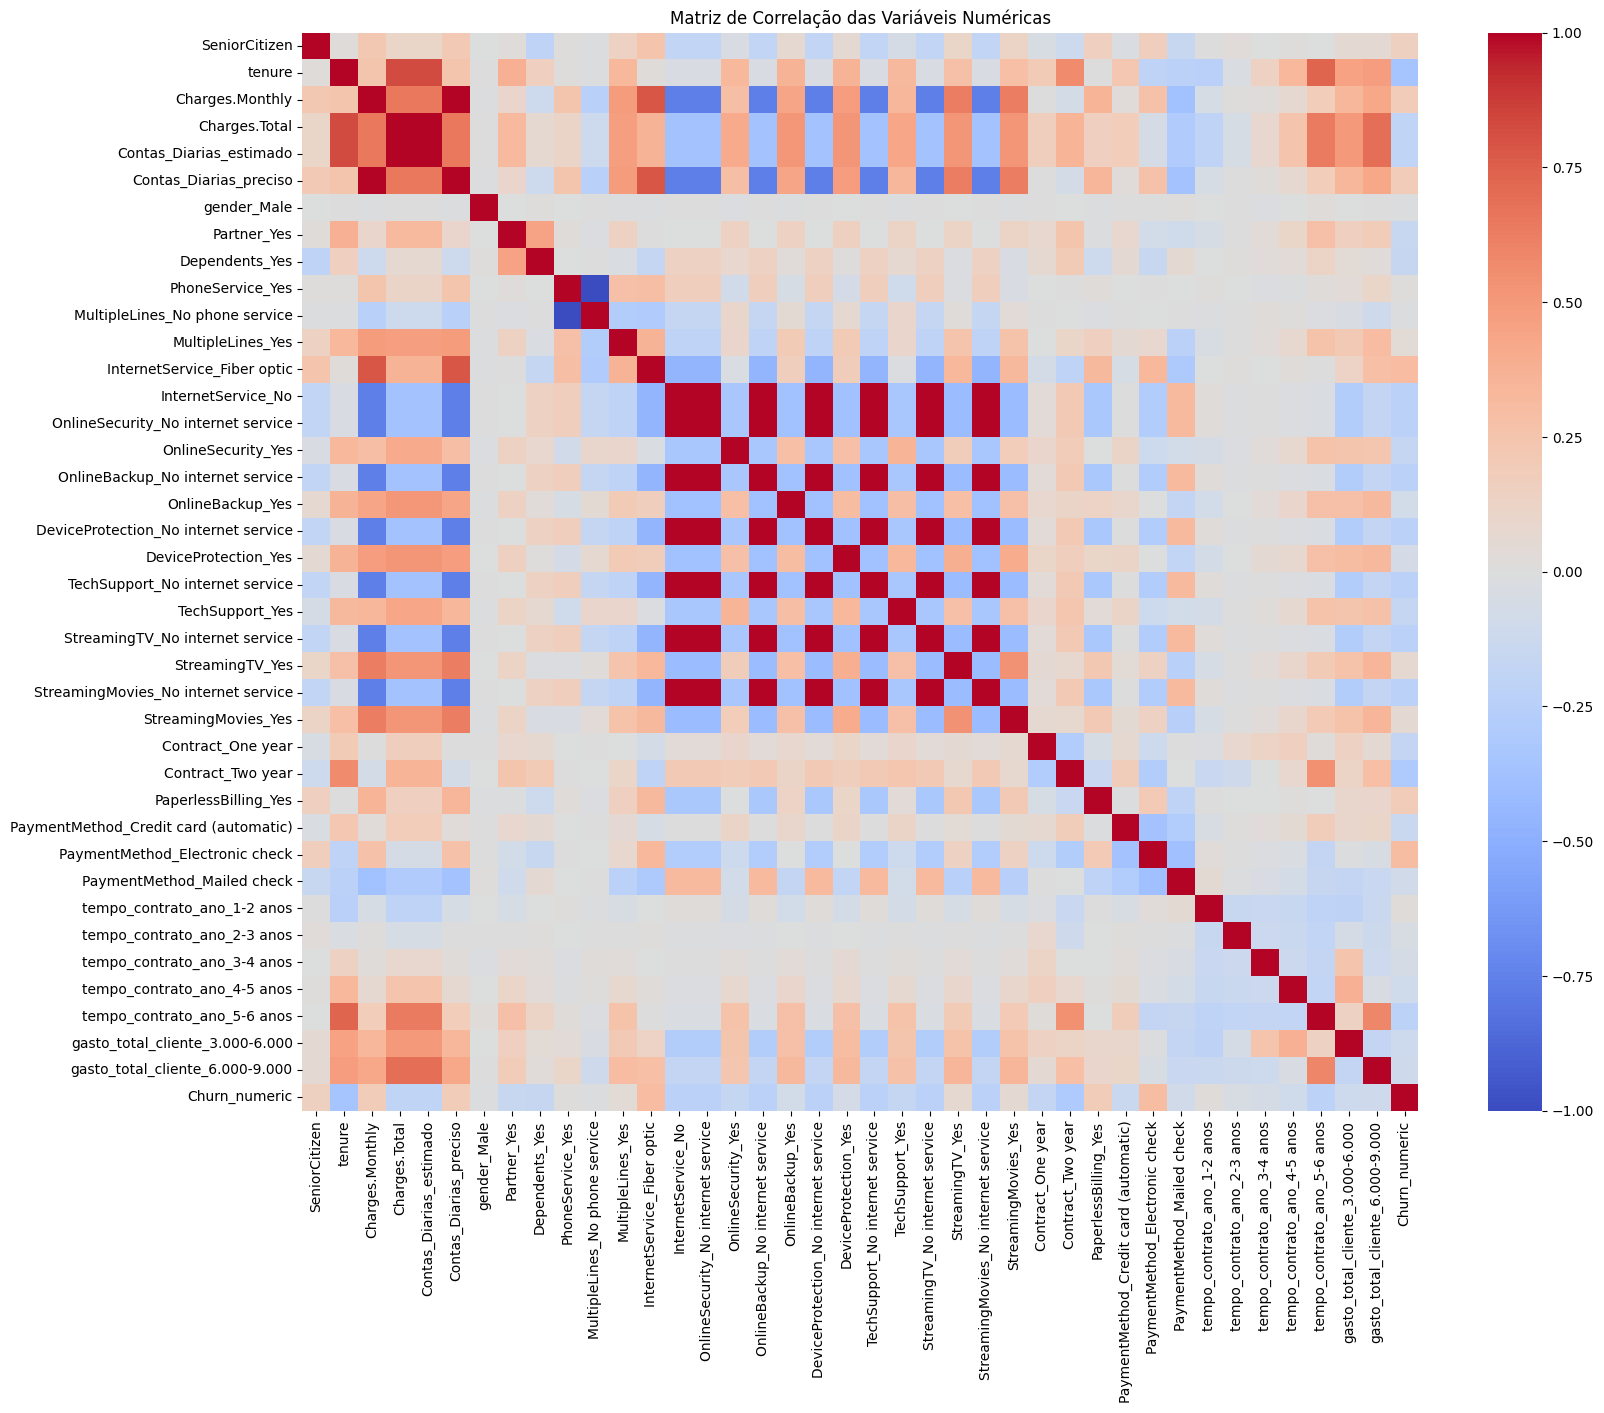


Correlação com a variável Churn:
Churn_numeric                            1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
Charges.Monthly                          0.192858
Contas_Diarias_preciso                   0.192112
PaperlessBilling_Yes                     0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
tempo_contrato_ano_1-2 anos              0.019929
PhoneService_Yes                         0.011691
gender_Male                             -0.008545
MultipleLines_No phone service          -0.011691
tempo_contrato_ano_2-3 anos             -0.040997
tempo_contrato_ano_3-4 anos             -0.059579
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
tempo_contrato_a

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Converter a coluna 'Churn' para numérica (se ainda não foi feita em dados_encoded)
# Verificamos o tipo antes para evitar erro caso já seja numérica
if dados_encoded['Churn'].dtype == 'object':
    dados_encoded['Churn_numeric'] = dados_encoded['Churn'].map({'No': 0, 'Yes': 1})
else:
    dados_encoded['Churn_numeric'] = dados_encoded['Churn']


# Selecionar apenas as colunas numéricas para a matriz de correlação
# Incluímos a nova coluna numérica de Churn
colunas_numericas = dados_encoded.select_dtypes(include=['float64', 'int64', 'bool', 'int32']).columns.tolist()
# Garantir que a coluna 'Churn_numeric' está incluída e 'Churn' original não
if 'Churn' in colunas_numericas:
    colunas_numericas.remove('Churn')
if 'Churn_numeric' not in colunas_numericas:
     colunas_numericas.append('Churn_numeric')


dados_numericos = dados_encoded[colunas_numericas]

# Calcular a matriz de correlação
matriz_correlacao = dados_numericos.corr()

# Visualizar a matriz de correlação usando um heatmap
plt.figure(figsize=(18, 14)) # Ajuste o tamanho conforme necessário
sns.heatmap(matriz_correlacao, annot=False, cmap='coolwarm', fmt=".2f") # annot=True para mostrar valores
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

# Opcional: Exibir as correlações com a variável alvo 'Churn_numeric' ordenadas
print("\nCorrelação com a variável Churn:")
print(matriz_correlacao['Churn_numeric'].sort_values(ascending=False))

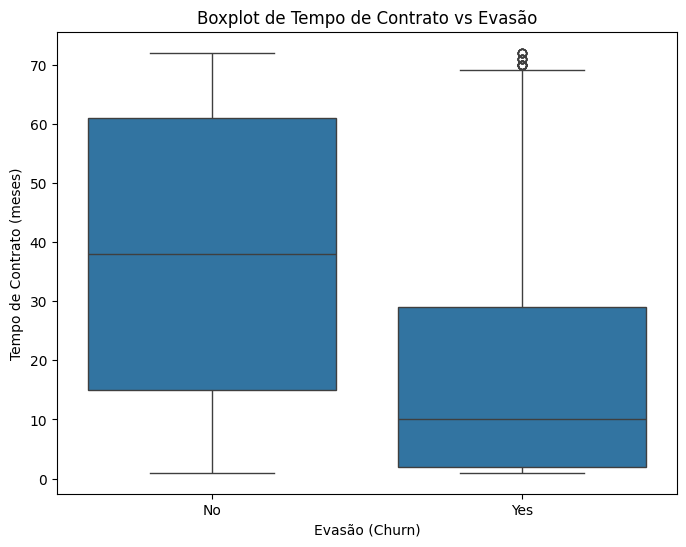

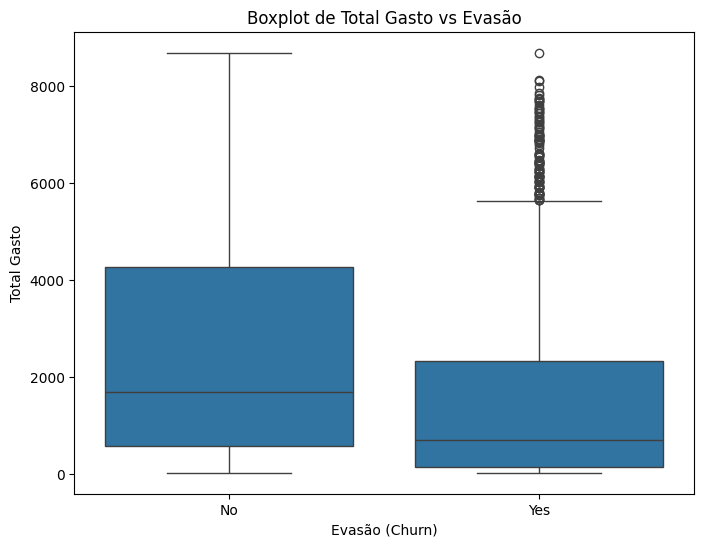

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot para Tempo de contrato (tenure) vs Evasão (Churn)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='tenure', data=dados)
plt.title('Boxplot de Tempo de Contrato vs Evasão')
plt.xlabel('Evasão (Churn)')
plt.ylabel('Tempo de Contrato (meses)')
plt.show()

# Boxplot para Total gasto (Charges.Total) vs Evasão (Churn)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Charges.Total', data=dados)
plt.title('Boxplot de Total Gasto vs Evasão')
plt.xlabel('Evasão (Churn)')
plt.ylabel('Total Gasto')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

# Dividir os dados em conjuntos de treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_res_scaled, y_res, test_size=0.2, random_state=42, stratify=y_res)

# Exibir o tamanho dos conjuntos resultantes para verificar a divisão
print("Tamanho do conjunto de treino (features):", X_train.shape)
print("Tamanho do conjunto de teste (features):", X_test.shape)
print("Tamanho do conjunto de treino (target):", y_train.shape)
print("Tamanho do conjunto de teste (target):", y_test.shape)

Tamanho do conjunto de treino (features): (8260, 39)
Tamanho do conjunto de teste (features): (2066, 39)
Tamanho do conjunto de treino (target): (8260,)
Tamanho do conjunto de teste (target): (2066,)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Modelo de Regressão Logística
# Usaremos os dados padronizados (X_train)
model_lr = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' é bom para conjuntos de dados pequenos
model_lr.fit(X_train, y_train)

print("Regressão Logística treinada.")

# 2. Modelo de Random Forest
# Usaremos os dados padronizados (X_train) - Random Forest não exige, mas funciona com dados padronizados
model_rf = RandomForestClassifier(random_state=42, n_estimators=100) # n_estimators é o número de árvores
model_rf.fit(X_train, y_train)

print("Random Forest treinado.")

Regressão Logística treinada.
Random Forest treinado.


--- Avaliação do Modelo de Regressão Logística ---
Acurácia: 0.8446272991287512
Precisão: 0.844294003868472
Recall: 0.8451113262342691
F1-score: 0.8447024673439768


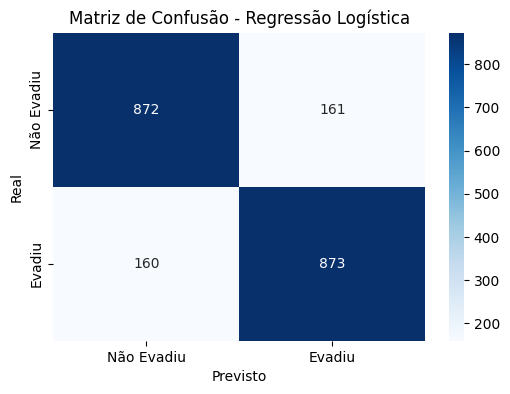



--- Avaliação do Modelo de Random Forest ---
Acurácia: 0.8635043562439496
Precisão: 0.8579599618684461
Recall: 0.8712487899322362
F1-score: 0.8645533141210374


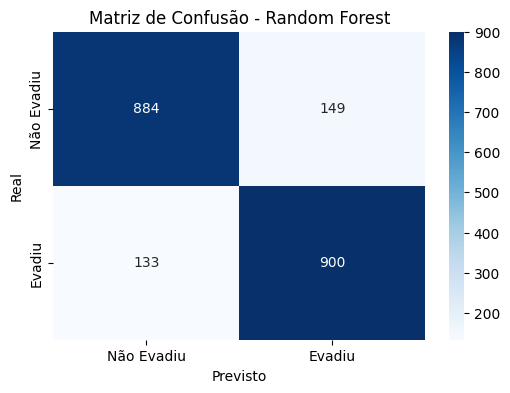

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Avaliação do Modelo de Regressão Logística
y_pred_lr = model_lr.predict(X_test)

print("--- Avaliação do Modelo de Regressão Logística ---")
print("Acurácia:", accuracy_score(y_test, y_pred_lr))
print("Precisão:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))

# Matriz de Confusão para Regressão Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Evadiu', 'Evadiu'], yticklabels=['Não Evadiu', 'Evadiu'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

print("\n")

# Avaliação do Modelo de Random Forest
y_pred_rf = model_rf.predict(X_test)

print("--- Avaliação do Modelo de Random Forest ---")
print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("Precisão:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

# Matriz de Confusão para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Evadiu', 'Evadiu'], yticklabels=['Não Evadiu', 'Evadiu'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

In [22]:
import pandas as pd

# Importância das Variáveis na Regressão Logística
# Os coeficientes representam a mudança no log-odds de Churn para uma unidade de mudança na feature
coeficientes_lr = pd.DataFrame({'Feature': X_train.columns, 'Coeficiente': model_lr.coef_[0]})
coeficientes_lr = coeficientes_lr.sort_values(by='Coeficiente', ascending=False)

print("--- Importância das Variáveis (Coeficientes) - Regressão Logística ---")
display(coeficientes_lr)

print("\n")

# Importância das Variáveis no Random Forest
importancias_rf = pd.DataFrame({'Feature': X_train.columns, 'Importância': model_rf.feature_importances_})
importancias_rf = importancias_rf.sort_values(by='Importância', ascending=False)

print("--- Importância das Variáveis - Random Forest ---")
display(importancias_rf)

--- Importância das Variáveis (Coeficientes) - Regressão Logística ---


,Feature,Coeficiente
12,InternetService_Fiber optic,4.038579
9,PhoneService_Yes,2.557691
36,tempo_contrato_ano_5-6 anos,1.661358
23,StreamingTV_Yes,1.546468
25,StreamingMovies_Yes,1.503139
35,tempo_contrato_ano_4-5 anos,1.235514
10,MultipleLines_No phone service,1.211762
34,tempo_contrato_ano_3-4 anos,0.936635
11,MultipleLines_Yes,0.919514
19,DeviceProtection_Yes,0.724715




--- Importância das Variáveis - Random Forest ---


,Feature,Importância
3,Charges.Total,0.116782
1,tenure,0.111761
4,Contas_Diarias_estimado,0.099371
2,Charges.Monthly,0.098131
30,PaymentMethod_Electronic check,0.093997
5,Contas_Diarias_preciso,0.065502
12,InternetService_Fiber optic,0.046644
28,PaperlessBilling_Yes,0.040598
27,Contract_Two year,0.036263
6,gender_Male,0.020075


## Relatório de Análise de Evasão de Clientes (Churn)

Este relatório detalha a análise exploratória e a modelagem preditiva realizadas para identificar os principais fatores que influenciam a evasão de clientes em uma empresa de telecomunicações, e propõe estratégias de retenção baseadas nos resultados obtidos.

**1. Introdução e Objetivo**

A evasão de clientes (churn) é um desafio significativo para as empresas, especialmente no setor de telecomunicações, onde a concorrência é alta. O objetivo deste projeto foi analisar os dados dos clientes para identificar os padrões e fatores que levam à evasão, construir modelos preditivos para prever quais clientes têm maior probabilidade de evadir, e propor estratégias de retenção eficazes.

**2. Pré-processamento e Análise de Dados**

*   **Carregamento e Limpeza:** Os dados foram carregados a partir do arquivo `dados_tratados.csv`. Colunas identificadoras únicas, como `customerID`, foram removidas por não agregarem valor preditivo.
*   **Codificação de Variáveis Categóricas:** Variáveis categóricas (como tipo de serviço de internet, método de pagamento, etc.) foram transformadas em formato numérico utilizando One-Hot Encoding, tornando-as compatíveis com algoritmos de machine learning. A coluna alvo `Churn` foi mantida separada.
*   **Análise de Desbalanceamento de Classes:** Foi identificado um desequilíbrio significativo na variável alvo `Churn`, com a classe 'No' (não evasão) sendo majoritária (aproximadamente 73%) e a classe 'Yes' (evasão) minoritária (aproximadamente 27%).
*   **Tratamento de Desbalanceamento:** Para lidar com o desequilíbrio e melhorar o desempenho dos modelos na previsão da classe minoritária, a técnica de Oversampling utilizando **SMOTE** (Synthetic Minority Over-sampling Technique) foi aplicada. Isso resultou em um conjunto de dados balanceado, com igual número de exemplos para as classes 'No' e 'Yes'.
*   **Padronização de Dados:** As features do conjunto de dados balanceado (`X_res`) foram padronizadas usando `StandardScaler`. Esta etapa é crucial para modelos que são sensíveis à escala das features, como Regressão Logística.
*   **Análise Exploratória e Correlação:**
    *   A matriz de correlação revelou que variáveis como `tenure` (tempo de contrato), `Charges.Total` (total gasto), `InternetService_Fiber optic` (serviço de fibra ótica) e `PaymentMethod_Electronic check` (cheque eletrônico) apresentaram as correlações mais fortes com a evasão.
    *   Boxplots confirmaram visualmente que clientes que evadem tendem a ter menor tempo de contrato e menor gasto total em comparação com clientes que permanecem ativos.

**3. Modelagem Preditiva**

Dois modelos de classificação foram treinados nos dados balanceados e padronizados para prever a evasão:

*   **Modelo 1: Regressão Logística:** Escolhido por ser um modelo linear interpretável, adequado para classificação binária e que exige padronização dos dados.
*   **Modelo 2: Random Forest:** Escolhido por ser um modelo baseado em ensemble de árvores, robusto, capaz de capturar relações não-lineares e não sensível à escala dos dados.

Os dados foram divididos em conjuntos de treino (80%) e teste (20%) para avaliação.

**4. Avaliação dos Modelos**

Os modelos foram avaliados no conjunto de teste utilizando as métricas de Acurácia, Precisão, Recall, F1-score e Matriz de Confusão.

| Métrica          | Regressão Logística | Random Forest |
| :--------------- | :------------------ | :------------ |
| Acurácia         | ~0.845              | ~0.864        |
| Precisão         | ~0.844              | ~0.858        |
| Recall           | ~0.845              | ~0.871        |
| F1-score         | ~0.845              | ~0.865        |

*   O modelo de **Random Forest** apresentou um desempenho ligeiramente superior em todas as métricas, demonstrando uma maior capacidade de prever corretamente a evasão e a não evasão no conjunto de teste.
*   Ambos os modelos mostraram um bom desempenho no conjunto de teste balanceado, sugerindo que não estão sofrendo de underfitting severo. A avaliação de overfitting exigiria a comparação com as métricas no conjunto de treino.

**5. Análise de Importância das Variáveis**

A análise da importância das variáveis nos modelos revelou os principais fatores que influenciam a evasão:

*   **Regressão Logística (Análise de Coeficientes):** Destacou o serviço de **Fibra Ótica**, ter **Serviço de Telefone**, e faixas de **Tempo de Contrato** mais longas (de forma contraintuitiva para as faixas mais longas, o que pode ser uma limitação do modelo linear ou da interação com outras features) como tendo alta influência positiva ou negativa na probabilidade de evasão. `Charges.Monthly` e `tenure` tiveram grandes coeficientes negativos.
*   **Random Forest (Análise de Importância das Features):** Identificou o **Gasto Total (`Charges.Total`)**, **Tempo de Contrato (`tenure`)**, **Gasto Mensal (`Charges.Monthly`)**, **Método de Pagamento (Cheque Eletrônico)** e **Serviço de Internet (Fibra Ótica)** como as features mais importantes para a previsão de evasão. Esta análise se alinha melhor com as análises exploratórias e intuitivas.

**Principais Fatores que Afetam a Evasão:**

Com base na consistência entre a análise exploratória e a importância das variáveis no modelo de melhor desempenho (Random Forest), os principais fatores que afetam a evasão de clientes são:

*   **Tempo de Contrato (Tenure):** Clientes com menor tempo de contrato são mais propensos a evadir.
*   **Gasto (Charges.Total e Charges.Monthly):** Clientes com menor gasto total e mensal tendem a evadir mais.
*   **Tipo de Serviço de Internet:** Clientes com serviço de Fibra Ótica têm maior probabilidade de evadir.
*   **Método de Pagamento:** Clientes que utilizam Cheque Eletrônico apresentam maior propensão à evasão.
*   **Tipo de Contrato:** Clientes com contratos de curto prazo (mês a mês) evadem mais do que aqueles com contratos mais longos (anual, dois anos).

**6. Estratégias de Retenção Propostas**

Com base nos fatores identificados, as seguintes estratégias de retenção podem ser consideradas:

*   **Foco em Clientes Novos:** Implementar programas de boas-vindas e acompanhamento intensivo nos primeiros meses de contrato para aumentar o engajamento e reduzir a evasão inicial (abordando o fator Tempo de Contrato).
*   **Incentivo a Contratos Mais Longos:** Oferecer descontos, benefícios ou planos diferenciados para clientes que optarem por contratos anuais ou de dois anos.
*   **Análise de Clientes de Fibra Ótica:** Investigar as razões pelas quais clientes com Fibra Ótica estão evadindo mais. Pode estar relacionado ao custo, qualidade do serviço, ou ofertas concorrentes. Criar planos ou benefícios específicos para reter este segmento.
*   **Promoção de Métodos de Pagamento Automáticos:** Incentivar clientes que usam Cheque Eletrônico a migrarem para métodos de pagamento automáticos (cartão de crédito, débito em conta), que geralmente estão associados a menor evasão. Oferecer pequenos descontos ou conveniências pode ajudar.
*   **Programas de Fidelidade e Reconhecimento:** Criar programas que recompensem clientes de longo prazo (maior `tenure`) com benefícios exclusivos, descontos ou atendimento prioritário para reforçar a lealdade.
*   **Ofertas Personalizadas:** Utilizar os insights do modelo para identificar clientes com alta probabilidade de evasão e direcionar ofertas de retenção personalizadas, como descontos, upgrade de serviço ou atendimento proativo.
*   **Análise de Preços:** Reavaliar a estrutura de preços, especialmente para clientes com menor gasto, e considerar ofertas ou pacotes que possam aumentar o valor percebido e incentivar a permanência.

**7. Próximos Passos**

*   Implementar e testar as estratégias de retenção propostas.
*   Monitorar continuamente as taxas de evasão e o desempenho das estratégias.
*   Revisar e refinar os modelos preditivos periodicamente com novos dados.
*   Realizar análises de custo-benefício das estratégias de retenção.

Este relatório fornece uma base sólida para entender a evasão de clientes e tomar ações direcionadas para a retenção.